# Gradient Descent in One Variable — Part 1 (Motivation)

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture introducing
**gradient descent** (Week 2 — Gradients and Gradient Descent).

This notebook explains:

- why solving $f'(x) = 0$ **analytically** quickly becomes impractical
- the example $f(x) = e^{x} - \ln x$, whose minimum is the famous **Omega constant**
- the idea of an **iterative** method: sample left/right, step toward the smaller value
- a Python implementation of that naive search
- how it sets up the *real* gradient descent (next lecture)

This notebook follows the repository `GUIDELINES.md` template and continues directly
from *Optimization Using Gradients — Analytical Method*.

## 1. Introduction

> *"When you try to get exact solutions analytically, these problems can get really
> complicated really fast, especially in higher dimensions... The method is called
> gradient descent."*

So far we minimized functions by solving $\nabla f = 0$ exactly. That is powerful but
often **impossible in closed form**. Gradient descent is an **iterative** alternative
that works even when the equations cannot be solved by hand — and it scales to many
variables.

We start in **one variable** to build intuition.

After this notebook you will be able to:

- recognize when an analytical solution is impractical
- describe the iterative "step toward lower values" idea
- implement a simple version and see it converge

## 2. The example: $f(x) = e^{x} - \ln x$

The function is smooth (for $x > 0$) and has a single minimum. From earlier lessons we
know the recipe: compute $f'(x)$ and set it to zero.

$$
f(x) = e^{x} - \ln x
\qquad\Rightarrow\qquad
f'(x) = e^{x} - \frac{1}{x},
$$

since $\dfrac{d}{dx}e^{x} = e^{x}$ and $\dfrac{d}{dx}\ln x = \dfrac{1}{x}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x = sp.symbols('x', positive=True)
f = sp.exp(x) - sp.log(x)
fp = sp.diff(f, x)
print("f(x)  =", f)
print("f'(x) =", fp)

f(x)  = exp(x) - log(x)
f'(x) = exp(x) - 1/x


## 3. Why the analytical solution is hard

Setting $f'(x) = 0$:

$$
e^{x} - \frac{1}{x} = 0 \quad\Longleftrightarrow\quad e^{x} = \frac{1}{x}.
$$

> *"I challenge you to try — it's actually pretty hard to do analytically. The solution is
> $0.5671\ldots$, a famous number known as the **omega constant**."*

Multiplying both sides by $x$ gives $x e^{x} = 1$, whose solution is the **Lambert
$W$** value $x = W(1) = \Omega$, the **Omega constant** $\Omega \approx 0.567143$.
There is no elementary closed form — exactly the situation that motivates an iterative
method.

In [2]:
# There is no elementary solution; SymPy expresses it via the Lambert W function.
sol = sp.solve(sp.Eq(sp.exp(x), 1/x), x)
print("Symbolic solution:", sol)

omega = sp.LambertW(1)
print("Omega constant  Ω = W(1) =", sp.N(omega, 12))

# sanity check: Ω satisfies e^Ω = 1/Ω
print("check e^Ω - 1/Ω =", sp.N(sp.exp(omega) - 1/omega, 6))

Symbolic solution: [LambertW(1)]
Omega constant  Ω = W(1) = 0.567143290410
check e^Ω - 1/Ω = -0.e-127


## 4. The idea: an iterative search

If we cannot solve it directly, we **search**:

> *"Let's pick some random value... move to the left a little and to the right a little.
> Which of these two points is better? Since we're minimizing, go for the one with the
> smaller value. Then repeat. Eventually both sides have a higher value, so we settle for
> this point — it may not be the exact minimum, but it's close enough."*

So the naive algorithm is:

1. Start at some $x$.
2. Look a small step $h$ to the **left** ($x-h$) and **right** ($x+h$).
3. Move to whichever has the **smaller** $f$ value.
4. Stop when **both** neighbours are higher — you are near the minimum.

In [3]:
def f_num(x):
    return np.exp(x) - np.log(x)

def naive_search(f, x0, h=0.1, max_steps=100):
    x = x0
    history = [x]
    for _ in range(max_steps):
        left, right = x - h, x + h
        # pick the neighbour with the smaller value, if it improves on x
        candidates = [(f(left), left), (f(right), right)]
        best_val, best_x = min(candidates)
        if best_val < f(x):
            x = best_x
            history.append(x)
        else:
            break  # both neighbours are higher -> settle here
    return x, history

x_star, hist = naive_search(f_num, x0=1.5, h=0.1)
print(f"Naive search stopped at x = {x_star:.4f},  f(x) = {f_num(x_star):.5f}")
print(f"Omega constant (true min) ≈ 0.5671")
print(f"Steps taken: {len(hist) - 1}")

Naive search stopped at x = 0.6000,  f(x) = 2.33294
Omega constant (true min) ≈ 0.5671
Steps taken: 9


## 5. Visualizing the search

The function and the path taken by the naive left/right search toward the minimum.

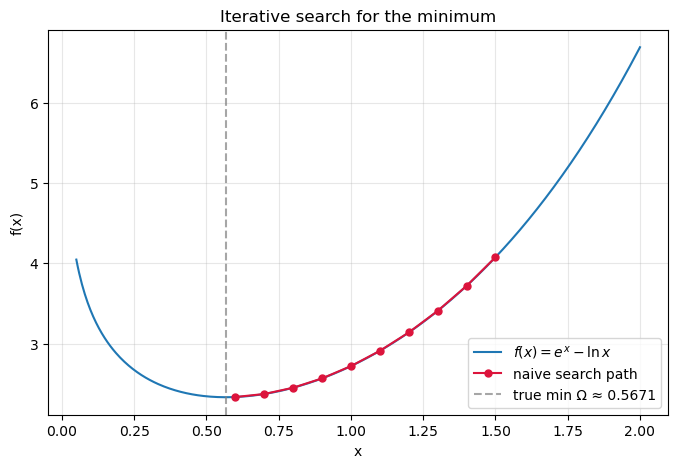

In [4]:
xs = np.linspace(0.05, 2.0, 400)
ys = f_num(xs)

plt.figure(figsize=(8, 5))
plt.plot(xs, ys, label=r"$f(x)=e^{x}-\ln x$")

hist = np.array(hist)
plt.plot(hist, f_num(hist), "o-", color="crimson", markersize=5,
         label="naive search path")

omega_val = 0.5671432904
plt.axvline(omega_val, color="gray", linestyle="--", alpha=0.7,
            label=f"true min Ω ≈ {omega_val:.4f}")

plt.title("Iterative search for the minimum")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 6. Good, but improvable

> *"This method is not bad, but we can actually improve it a lot to get really, really
> close to the minimum."*

The naive search has weaknesses:

- the **fixed step** $h$ limits how close you can get,
- it ignores **how steep** the function is — far from the minimum you'd want big steps,
  near it small ones.

The next lecture fixes this by stepping in proportion to the **derivative** (the
gradient): that is **gradient descent** proper,

$$
x_{\text{new}} = x_{\text{old}} - \alpha\, f'(x_{\text{old}}),
$$

where $\alpha$ is the learning rate.

## 7. Exercises

### Basic
1. Compute $f'(x)$ for $f(x) = e^{x} - \ln x$.
2. Write the equation you would solve to find the minimum, and explain why it is hard.

### Intermediate
3. Run the naive search from a different starting point (e.g. $x_0 = 0.2$) and compare the
   result.
4. What happens to the final accuracy if you shrink the step $h$ from $0.1$ to $0.01$?

### Advanced
5. The minimum satisfies $x e^{x} = 1$, i.e. $x = W(1) = \Omega$. Verify numerically that
   $\Omega \approx 0.567143$ solves $e^{x} = 1/x$.
6. Explain one disadvantage of using a *fixed* step size, and how scaling the step by the
   derivative would help.

## 8. Solutions / Checks

In [5]:
x = sp.symbols('x', positive=True)
f = sp.exp(x) - sp.log(x)
print("1. f'(x) =", sp.diff(f, x))

# 3. different start
xs3, _ = naive_search(f_num, x0=0.2, h=0.1)
print(f"3. from x0=0.2 -> x = {xs3:.4f}")

# 4. smaller step
xs4, h4 = naive_search(f_num, x0=1.5, h=0.01, max_steps=1000)
print(f"4. with h=0.01 -> x = {xs4:.4f} ({len(h4)-1} steps)")

# 5. verify Omega
omega = float(sp.N(sp.LambertW(1)))
print(f"5. Ω = {omega:.6f}, e^Ω - 1/Ω = {np.exp(omega) - 1/omega:.2e}")

print("6. A fixed step can't get closer than ~h to the minimum and is slow far away; "
      "scaling the step by f'(x) takes big steps on steep parts and small steps near the min.")

1. f'(x) = exp(x) - 1/x
3. from x0=0.2 -> x = 0.6000
4. with h=0.01 -> x = 0.5700 (93 steps)
5. Ω = 0.567143, e^Ω - 1/Ω = 0.00e+00
6. A fixed step can't get closer than ~h to the minimum and is slow far away; scaling the step by f'(x) takes big steps on steep parts and small steps near the min.


## 9. Conclusion

- Solving $f'(x) = 0$ analytically can be **impractical** — for $f(x)=e^x-\ln x$ the
  minimum is the **Omega constant** $\Omega \approx 0.5671$, with no elementary form.
- An **iterative** search — sample left/right, step toward the smaller value, stop when
  both neighbours are higher — gets us close without solving anything by hand.
- Its fixed step size is a limitation; scaling the step by the **derivative** gives the
  much better **gradient descent**, covered next.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/gradients_1.mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 2) lecture introducing **gradient descent in one variable**. Key spoken
points, lightly cleaned:

> Analytical optimization gets complicated fast, especially in higher dimensions, so we
> introduce an iterative, powerful method: gradient descent. Starting in one variable,
> take $f(x)=e^{x}-\ln x$, which is smooth with a single minimum. We could set
> $f'(x)=e^{x}-1/x=0$, i.e. $e^{x}=1/x$, but that is hard analytically — the solution is
> $0.5671\ldots$, the omega constant. Instead, pick a random point, step a little left and
> right, and move to whichever value is smaller; repeat until both neighbours are higher,
> then settle there as "close enough." This works but can be improved a lot — shown in the
> next video.